# Проект «Гаранты»: сбор, предобработка, анализ, классификация и мониторинг

Ноутбук реализует конвейер мониторинга гарантов и поручителей по методологии проекта
(`../methodology_skill.md`): **сбор** из Oracle / PostgreSQL / Vertica → **предобработка** и
правовые шлюзы → **разведочный анализ** → **feature engineering** (портрет гаранта) →
**классификация** (сегменты: заплатит / не заплатит / пустая оболочка / прячет / нет основания) →
**дашборд мониторинга** с ежедневным обновлением.

Юрисдикция — РК. Ключевые правовые факты (сверено с adilet.zan.kz): **гарантия — солидарная**
ответственность (ГК РК ст. 329), **поручительство — субсидиарная** (ст. 330); начисления
обрезаются после 90 дней просрочки (НП ВС РК № 7 п. 18); `guarantee_alive` (ст. 336) — жёсткий
шлюз; из реализуемой базы исключаются единственное жильё и защищённый доход (ст. 61, 95, 98).

**Запуск в VS Code:** выбрать интерпретатор Anaconda (Python 3.13, `python3`). Данные —
синтетические (`src/generate_synthetic_garanty.py`), но код сбора рассчитан и на живые БД.

## 0. Настройка окружения

In [1]:
import os, sys, warnings, json
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 160)

# find project root robustly (works from notebooks/ or project root)
def find_root(start):
    p = os.path.abspath(start)
    for _ in range(6):
        if os.path.exists(os.path.join(p, "methodology_skill.md")):
            return p
        p = os.path.dirname(p)
    return os.path.abspath(os.path.join(start, ".."))
ROOT = find_root(os.getcwd())
SRC = os.path.join(ROOT, "src")
if SRC not in sys.path: sys.path.insert(0, SRC)
AS_OF = pd.Timestamp("2026-09-04")   # дата среза (as-of), передаётся явно
print("ROOT:", ROOT)

ROOT: /Users/gg/Desktop/SoftCol/projects/garanty


## 1. Сбор данных из Oracle, PostgreSQL, Vertica

Первый шаг задачи — собрать датасеты по кредитам и гарантиям из трёх источников. Модуль
`db_collect` содержит реальные SQL-запросы и драйверы (oracledb, psycopg2, vertica-python) и
при отсутствии живого соединения читает локальные синтетические таблицы того же формата, поэтому
ноутбук исполняется офлайн, а тот же код работает против боевых БД при задании переменных
окружения.

| Источник | Что даёт |
|---|---|
| **Oracle** (АБС) | кредиты: остаток, ставка, DPD, статус |
| **PostgreSQL** (collections/CRM) | договоры гарантии/поручительства, мастер гарантов, связанные лица, контакты |
| **Vertica** (хранилище) | обороты/переводы, депозиты, зарплата, имущество |

In [2]:
import db_collect
data = db_collect.collect_all()
for k, df in data.items():
    print(f"{k:18s} {df.shape[0]:>7,} строк x {df.shape[1]:>2} колонок")
credits   = data["credits"]
guarantees= data["guarantees"]
guarantors= data["guarantors"]
related   = data["related_persons"]
crm       = data["crm_contacts"]
tx        = data["transactions_agg"]
deposits  = data["deposits"]
salary    = data["salary"]
prop      = data["property"]
credits.head(3)

credits            100,000 строк x 13 колонок


guarantees         100,000 строк x  8 колонок
guarantors          85,000 строк x 11 колонок
related_persons    170,061 строк x  4 колонок
crm_contacts        95,119 строк x  3 колонок
transactions_agg    85,000 строк x  8 колонок
deposits            85,000 строк x  2 колонок
salary              85,000 строк x  4 колонок
property            85,000 строк x  4 колонок


,loan_id,debtor_id,guarantor_id,product,currency,principal,outstanding,interest_rate,open_date,maturity_date,dpd,loan_status,as_of_date
0,500000,58395,36236,Автокредит,KZT,3920000.0,3370900.0,0.4599,2023-11-19,2030-10-13,0,current,2026-09-04
1,500001,88042,14279,Ипотека,KZT,766000.0,517700.0,0.2712,2023-06-22,2026-06-06,0,current,2026-09-04
2,500002,77512,78300,Кредитная карта,KZT,8043000.0,2336000.0,0.2371,2025-11-08,2027-10-29,0,current,2026-09-04


## 2. Предобработка

Приводим типы, чистим и дедуплицируем контакты (телефон — слабый ключ, мастер-ключ — гарант),
затем собираем аналитическую базовую таблицу (ABT) на уровне договор × гарант и применяем
правовые шлюзы.

In [3]:
# --- 2.1 чистка и дедупликация контактов (телефоны) ---
import re
def clean_phone_kz(raw):
    if not isinstance(raw, str): return None
    digits = re.sub(r"\D", "", raw)
    if digits.startswith("8") and len(digits) == 11: digits = "7" + digits[1:]
    if digits.startswith("7") and len(digits) == 11: return "+" + digits
    if len(digits) == 10: return "+7" + digits
    return None
crm = crm.copy()
crm["phone_e164"] = crm["phone_raw"].map(clean_phone_kz)
before = len(crm)
crm_valid = crm.dropna(subset=["phone_e164"]).copy()
# дедуп: одна строка на (гарант, телефон); флаг общего номера (много лиц на один номер)
crm_dedup = crm_valid.drop_duplicates(subset=["guarantor_id", "phone_e164"])
shared = (crm_dedup.groupby("phone_e164")["guarantor_id"].nunique()
          .rename("n_persons_on_phone").reset_index())
crm_dedup = crm_dedup.merge(shared, on="phone_e164", how="left")
phones_per_g = crm_dedup.groupby("guarantor_id").agg(
    n_phones=("phone_e164", "nunique"),
    max_shared_degree=("n_persons_on_phone", "max")).reset_index()
print(f"CRM: {before:,} сырых → {len(crm_valid):,} валидных → {len(crm_dedup):,} после дедупа; "
      f"удалено дублей: {len(crm_valid)-len(crm_dedup):,}")
crm_dedup.head(3)

CRM: 95,119 сырых → 95,119 валидных → 88,746 после дедупа; удалено дублей: 6,373


,guarantor_id,phone_raw,is_duplicate_seed,phone_e164,n_persons_on_phone
0,1,+7 (731) 145-93-5,0,+77731145935,1
1,2,8725684085,0,+78725684085,1
2,3,+7 (715) 851-51-1,0,+77715851511,1


In [4]:
# --- 2.2 сборка ABT (join по guarantor_id / loan_id) ---
abt = (guarantees
       .merge(credits, on=["loan_id", "guarantor_id"], how="inner", suffixes=("", "_ora"))
       .merge(guarantors[["guarantor_id","person_type","region","full_name","iin_bin","age"]],
              on="guarantor_id", how="left")
       .merge(tx, on="guarantor_id", how="left")
       .merge(deposits, on="guarantor_id", how="left")
       .merge(salary, on="guarantor_id", how="left")
       .merge(prop, on="guarantor_id", how="left")
       .merge(phones_per_g, on="guarantor_id", how="left"))
rel_cnt = related.groupby("guarantor_id").size().rename("n_related").reset_index()
abt = abt.merge(rel_cnt, on="guarantor_id", how="left")
abt["n_related"] = abt["n_related"].fillna(0).astype(int)
abt["n_phones"] = abt["n_phones"].fillna(0).astype(int)
abt["max_shared_degree"] = abt["max_shared_degree"].fillna(0).astype(int)
for c in ["open_date","maturity_date","contract_date","obligation_due_date"]:
    abt[c] = pd.to_datetime(abt[c])
print("ABT:", abt.shape)

ABT: (100000, 41)


In [5]:
# --- 2.3 правовые шлюзы (методология р. 2) ---
abt["days_since_due"] = (AS_OF - abt["obligation_due_date"]).dt.days
abt["missed_1y_deadline"] = abt["days_since_due"] > 365           # ст.336: 1 год на иск
abt["limitation_risk"]    = abt["days_since_due"] > 3*365         # ст.178: исковая давность 3 года
abt["guarantee_alive"]    = abt["written_form"] & (~abt["missed_1y_deadline"])
usd = np.where(abt["currency"].eq("USD"), 470.0, 1.0)
outstanding_kzt = abt["outstanding"].to_numpy() * usd
d = abt["dpd"].to_numpy()
penalty = np.minimum(outstanding_kzt * 0.005 * np.minimum(d,90), outstanding_kzt*0.10)  # обрезка >90 дней
interest = outstanding_kzt * abt["interest_rate"].to_numpy() * np.minimum(d,90)/365.0
exposure_full = outstanding_kzt + penalty + interest
csum_kzt = abt["contract_sum"].to_numpy()*usd
abt["exposure_full"] = exposure_full.round(-2)
abt["legal_ceiling"] = np.where(abt["liability_type"].eq("гарантия"),
                                exposure_full, np.minimum(csum_kzt, exposure_full)).round(-2)
abt["legal_ceiling_effective"] = np.where(abt["guarantee_alive"], abt["legal_ceiling"], 0.0)
print("guarantee_alive:", f"{abt['guarantee_alive'].mean():.1%}",
      "| договоров без письменной формы:", int((~abt['written_form']).sum()))
abt[["contract_id","liability_type","dpd","exposure_full","legal_ceiling","guarantee_alive"]].head(4)

guarantee_alive: 83.7% | договоров без письменной формы: 1999


,contract_id,liability_type,dpd,exposure_full,legal_ceiling,guarantee_alive
0,800000,поручительство,0,3370900.0,3370900.0,True
1,800001,гарантия,0,517700.0,517700.0,True
2,800002,поручительство,0,2336000.0,2336000.0,True
3,800003,гарантия,49,2929800.0,2929800.0,True


## 3. Разведочный анализ (EDA)

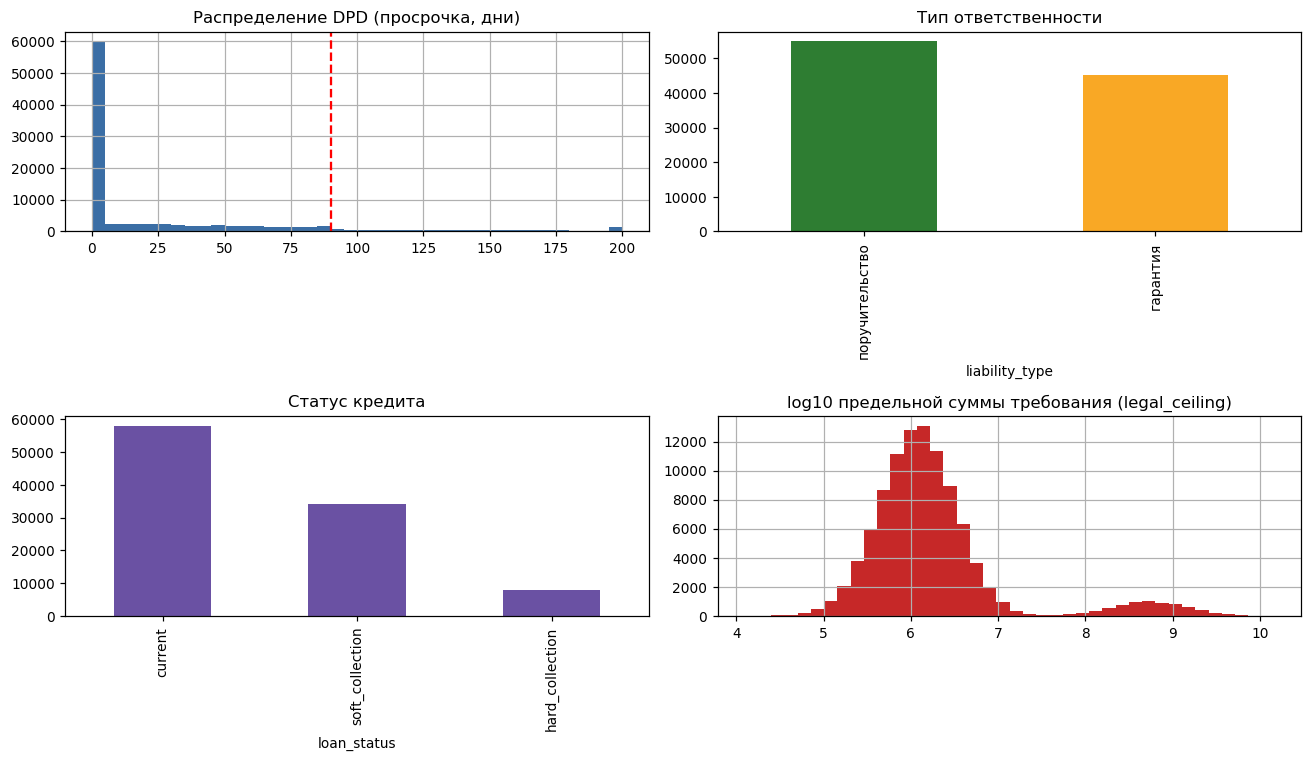

Доля в мягком взыскании (1-90 DPD): 34.1%


In [6]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({"figure.dpi":110, "font.size":9})
fig, ax = plt.subplots(2, 2, figsize=(12, 7))
abt["dpd"].clip(0,200).hist(bins=40, ax=ax[0,0], color="#3b6ea5")
ax[0,0].set_title("Распределение DPD (просрочка, дни)"); ax[0,0].axvline(90, color="red", ls="--")
abt["liability_type"].value_counts().plot.bar(ax=ax[0,1], color=["#2e7d32","#f9a825"])
ax[0,1].set_title("Тип ответственности")
abt["loan_status"].value_counts().plot.bar(ax=ax[1,0], color="#6a51a3")
ax[1,0].set_title("Статус кредита")
np.log10(abt["legal_ceiling"].clip(lower=1)).hist(bins=40, ax=ax[1,1], color="#c62828")
ax[1,1].set_title("log10 предельной суммы требования (legal_ceiling)")
plt.tight_layout(); plt.show()
print("Доля в мягком взыскании (1-90 DPD):", f"{abt['loan_status'].eq('soft_collection').mean():.1%}")

In [7]:
# ключевые агрегаты по типу ответственности
g = abt.groupby("liability_type").agg(
    n=("contract_id","size"),
    alive_share=("guarantee_alive","mean"),
    avg_dpd=("dpd","mean"),
    sum_ceiling_bln=("legal_ceiling_effective", lambda s: s.sum()/1e9)).round(3)
g

,n,alive_share,avg_dpd,sum_ceiling_bln
liability_type,,,,
гарантия,45087,0.837,26.732,2671.673
поручительство,54913,0.837,27.077,2732.144


## 4. Feature engineering — портрет гаранта

Строим признаки портрета (методология р. 6): ёмкость платить, реализуемые активы за вычетом
изъятий, риск вывода активов, отношения нагрузки и связей. **Важно для валидности:** признаки,
которые прямо определяют целевой сегмент (`capacity_to_pay`, `dissipation_risk`,
`realisable_assets`), исключаются из обучающих признаков модели, чтобы избежать утечки; модель
восстанавливает сегмент из «сырых» экономических и поведенческих сигналов.

In [8]:
# 4.1 ёмкость платить (KDN-style)
abt["capacity_to_pay"] = (abt["monthly_salary"].fillna(0)*0.5
                          + abt["turnover_3m"].fillna(0)/3*0.05
                          + abt["deposit_balance"].fillna(0)*0.1).round(-2)
# 4.2 реализуемые активы за вычетом изъятий (ст.61 единственное жильё, ст.95 50% дохода)
single_exempt = np.where(abt["is_single_dwelling"].fillna(False),
                         np.minimum(abt["property_value"].fillna(0), 25_000_000), 0.0)
realisable_property = np.maximum(abt["property_value"].fillna(0) - single_exempt, 0) + abt["vehicle_value"].fillna(0)
abt["realisable_assets"] = (abt["deposit_balance"].fillna(0) + realisable_property
                            + abt["monthly_salary"].fillna(0)*0.5*12).round(-2)
# 4.3 риск вывода активов (антифрод-сигналы)
abt["transfer_to_exposure"] = (abt["transfers_to_related_3m"].fillna(0) / (abt["exposure_full"]+1)).round(3)
def sig(x): return 1/(1+np.exp(-x))
abt["dissipation_risk"] = sig(-1.2
    + 1.4*(abt["transfer_to_exposure"]>0.3).astype(float)
    + 1.1*abt["recent_property_transfer"].fillna(False).astype(float)
    + 0.9*abt["salary_redirected"].fillna(False).astype(float)
    + 0.8*abt["consent_withdraw_attempt"].fillna(False).astype(float)
    + 0.6*(abt["dpd"]>30).astype(float)).round(4)
# 4.4 отношения / контактность
abt["dti_proxy"] = (abt["outstanding"]/ (abt["monthly_salary"].fillna(0)*12 + 1)).round(3)
abt["max_recoverable"] = np.minimum(abt["legal_ceiling_effective"], abt["realisable_assets"]).round(-2)
# ожидаемый возврат: p_recovery (прозрачная оценка) x max_recoverable x дисконт (методология р. 8)
_cap = abt["capacity_to_pay"]; _capz = (_cap - _cap.mean())/(_cap.std()+1)
abt["p_recovery"] = sig(-0.4 + 0.9*_capz - 1.3*abt["dissipation_risk"] - 0.01*abt["dpd"]
                        + 0.8*abt["guarantee_alive"].astype(float)).round(4)
abt["expected_recovery"] = (abt["p_recovery"]*abt["max_recoverable"]*0.85).round(-2)
print("новые признаки готовы:",
      ["capacity_to_pay","realisable_assets","dissipation_risk","transfer_to_exposure","dti_proxy","max_recoverable"])
abt[["capacity_to_pay","realisable_assets","dissipation_risk","max_recoverable"]].describe().round(0)

новые признаки готовы: ['capacity_to_pay', 'realisable_assets', 'dissipation_risk', 'transfer_to_exposure', 'dti_proxy', 'max_recoverable']


,capacity_to_pay,realisable_assets,dissipation_risk,max_recoverable
count,100000.0,100000.0,100000.0,100000.0
mean,196001.0,3569096.0,0.0,1149748.0
std,154169.0,4261994.0,0.0,1610665.0
min,17100.0,0.0,0.0,0.0
25%,103000.0,1246000.0,0.0,199375.0
50%,154600.0,2258000.0,0.0,776350.0
75%,237500.0,4218000.0,1.0,1514500.0
max,3072700.0,89902000.0,1.0,49955000.0


## 5. Классификация гарантов по сегментам

Целевой сегмент (методология р. 6): `will_pay` (заплатит), `cannot_pay` (не может),
`empty_shell` (пустая оболочка), `can_but_hiding` (может, но прячет), `no_basis` (нет основания —
обеспечение прекращено). Сначала правило-ориентир, затем градиентный бустинг с калибровкой и
проверкой по времени. Целевая метка синтетических данных известна (`segment` из генератора) —
используем её как истину для обучения и оценки.

In [9]:
# истинная метка из генератора (в бою заменяется размеченными исходами взыскания)
truth = pd.read_parquet(os.path.join(ROOT,"data","processed","abt_full.parquet"))[["contract_id","segment","will_pay"]]
abt = abt.merge(truth, on="contract_id", how="left")
print(abt["segment"].value_counts(normalize=True).round(3).to_string())

segment
will_pay          0.336
cannot_pay        0.249
no_basis          0.204
can_but_hiding    0.186
empty_shell       0.024


In [10]:
# 5.1 правило-ориентир (baseline) — прозрачное, для сравнения с моделью
MRP=3932; floor=3*MRP*12
def rule_segment(r):
    if not r["guarantee_alive"]: return "no_basis"
    cap_adeq = r["capacity_to_pay"] > abt["capacity_to_pay"].quantile(0.45)
    has_assets = r["realisable_assets"] > floor
    if r["dissipation_risk"]>0.55 and (cap_adeq or r["transfers_to_related_3m"]>0): return "can_but_hiding"
    if (not has_assets) and (not cap_adeq): return "empty_shell"
    if (not cap_adeq) and has_assets: return "cannot_pay"
    return "will_pay"
abt["segment_rule"] = abt.apply(rule_segment, axis=1)
from sklearn.metrics import accuracy_score, f1_score
print("Правило-ориентир: accuracy =", round(accuracy_score(abt["segment"], abt["segment_rule"]),3),
      "| macro-F1 =", round(f1_score(abt["segment"], abt["segment_rule"], average="macro"),3))

Правило-ориентир: accuracy = 0.844 | macro-F1 = 0.786


In [11]:
# 5.2 модель: градиентный бустинг. Признаки — «сырые» (без target-определяющих агрегатов), чтобы не было утечки.
LEAKY = {"segment","segment_rule","will_pay","capacity_to_pay","dissipation_risk","realisable_assets",
         "max_recoverable","legal_ceiling","legal_ceiling_effective","exposure_full","p_recovery",
         "expected_recovery","contract_id","loan_id","guarantor_id","debtor_id","iin_bin","full_name"}
raw_feats = ["dpd","principal","outstanding","interest_rate","contract_sum","liability_type","product",
             "currency","person_type","region","age","monthly_salary","salary_stability","turnover_3m",
             "deposit_balance","property_value","is_single_dwelling","vehicle_value","transfers_to_related_3m",
             "recent_property_transfer","salary_redirected","consent_withdraw_attempt","sessions_30d",
             "mau_active","n_related","n_phones","max_shared_degree","days_since_due","written_form",
             "guarantee_alive","limitation_risk","dti_proxy","transfer_to_exposure"]
X = abt[raw_feats].copy()
cat_cols = ["liability_type","product","currency","person_type","region"]
for c in cat_cols: X[c] = X[c].astype("category")
for c in X.columns:
    if X[c].dtype==bool: X[c]=X[c].astype(int)
    if X[c].dtype.kind in "fi": X[c]=X[c].fillna(0)
y = abt["segment"].astype("category")

# time-split (методология: делить по времени, не случайно): старые договоры -> train, свежие -> test
order = abt["contract_date"].rank(method="first")
tr = order <= order.quantile(0.7)
te = ~tr
print("train:", int(tr.sum()), "| test:", int(te.sum()))

train: 70000 | test: 30000


In [12]:
try:
    from lightgbm import LGBMClassifier
    clf = LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=48,
                         subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)
    clf.fit(X[tr], y[tr], categorical_feature=cat_cols)
    MODEL="LightGBM"
except Exception as e:
    from sklearn.ensemble import HistGradientBoostingClassifier
    Xe = X.copy()
    for c in cat_cols: Xe[c]=Xe[c].cat.codes
    clf = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.06, random_state=42)
    clf.fit(Xe[tr], y[tr]); X=Xe; MODEL="HistGBM(fallback)"
pred = clf.predict(X[te])
from sklearn.metrics import classification_report, confusion_matrix
print("Модель:", MODEL)
print("accuracy:", round(accuracy_score(y[te], pred),3),
      "| macro-F1:", round(f1_score(y[te], pred, average="macro"),3))
print(classification_report(y[te], pred, digits=3))

Модель: LightGBM
accuracy: 0.832 | macro-F1: 0.707


                precision    recall  f1-score   support

can_but_hiding      0.763     0.819     0.790      6473
    cannot_pay      0.846     0.918     0.880      8785
   empty_shell      0.879     0.387     0.537       827
      no_basis      0.998     0.295     0.456      2024
      will_pay      0.851     0.898     0.874     11891

      accuracy                          0.832     30000
     macro avg      0.867     0.663     0.707     30000
  weighted avg      0.841     0.832     0.820     30000



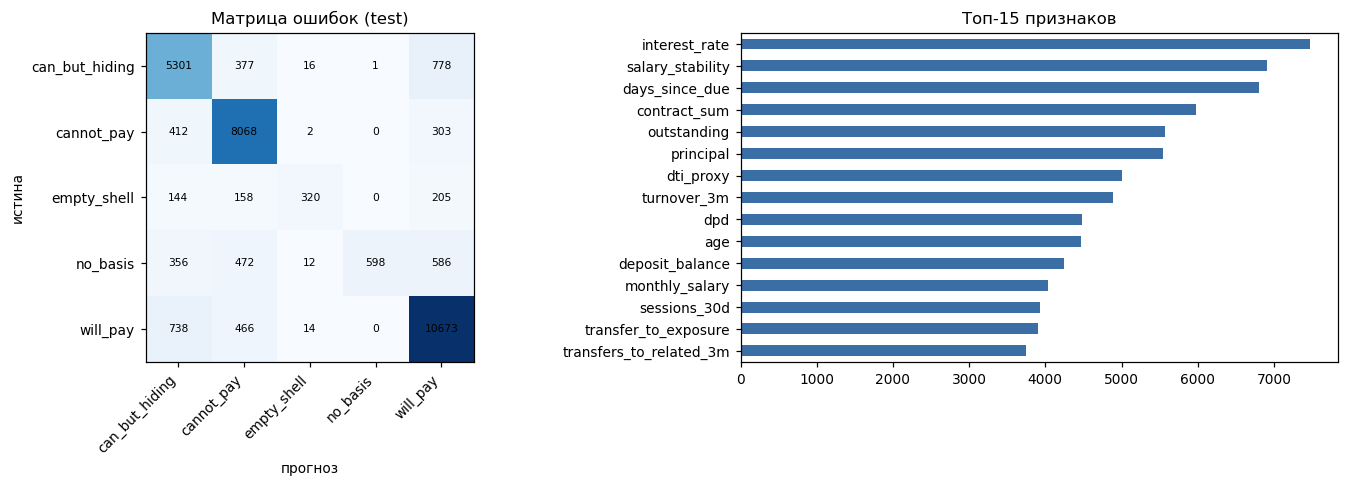

In [13]:
# 5.3 матрица ошибок и важность признаков
import matplotlib.pyplot as plt
labels = sorted(y.cat.categories.tolist())
cm = confusion_matrix(y[te], pred, labels=labels)
fig, ax = plt.subplots(1,2, figsize=(13,4.5))
im = ax[0].imshow(cm, cmap="Blues"); ax[0].set_xticks(range(len(labels))); ax[0].set_yticks(range(len(labels)))
ax[0].set_xticklabels(labels, rotation=45, ha="right"); ax[0].set_yticklabels(labels)
ax[0].set_title("Матрица ошибок (test)"); ax[0].set_xlabel("прогноз"); ax[0].set_ylabel("истина")
for i in range(len(labels)):
    for j in range(len(labels)): ax[0].text(j,i,cm[i,j],ha="center",va="center",fontsize=7)
imp = getattr(clf,"feature_importances_",None)
if imp is not None:
    s = pd.Series(imp, index=X.columns).sort_values().tail(15)
    s.plot.barh(ax=ax[1], color="#3b6ea5"); ax[1].set_title("Топ-15 признаков")
plt.tight_layout(); plt.show()

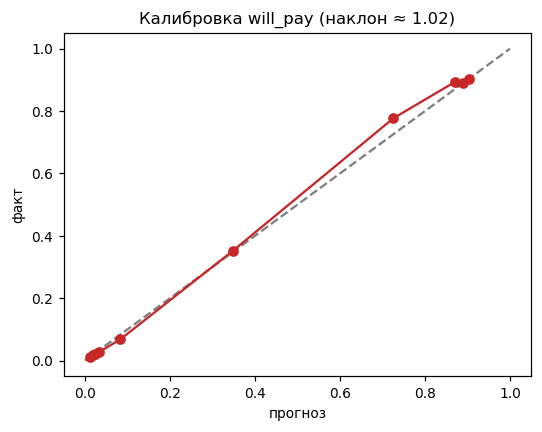

Наклон калибровки (цель ≈ 1): 1.025


In [14]:
# 5.4 калибровка бинарной оценки will_pay (денежный шаг: наклон и сдвиг)
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import calibration_curve
Xb = X.copy()
yb = abt["will_pay"].astype(int)
b = HistGradientBoostingClassifier(max_iter=250, learning_rate=0.06, random_state=1).fit(Xb[tr], yb[tr])
p = b.predict_proba(Xb[te])[:,1]
frac, mean_pred = calibration_curve(yb[te], p, n_bins=10, strategy="quantile")
import numpy as np
slope = np.polyfit(mean_pred, frac, 1)[0]
fig, ax = plt.subplots(figsize=(5,4))
ax.plot([0,1],[0,1],"--",color="grey"); ax.plot(mean_pred, frac, "o-", color="#c62828")
ax.set_title(f"Калибровка will_pay (наклон ≈ {slope:.2f})"); ax.set_xlabel("прогноз"); ax.set_ylabel("факт")
plt.tight_layout(); plt.show()
print("Наклон калибровки (цель ≈ 1):", round(slope,3))

## 6. Дашборд мониторинга (ежедневное обновление)

Интерактивный дашборд (plotly): портфель по DPD, распределение сегментов, доля действующего
обеспечения, ожидаемый возврат по сегментам, топ риска вывода активов и суточный тренд.
Экспортируется в HTML для встраивания; в проде пересобирается ежедневно на as-of срезе
(методология р. 11).

In [15]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
trend = pd.read_parquet(os.path.join(ROOT,"data","processed","daily_portfolio.parquet"))
seg_counts = abt["segment"].value_counts()
rec_by_seg = abt.groupby("segment")["expected_recovery"].sum()/1e9 if "expected_recovery" in abt else \
             abt.groupby("segment")["max_recoverable"].sum()/1e9
alive = abt["guarantee_alive"].mean()*100
top_dissip = (abt.sort_values("dissipation_risk", ascending=False)
              .head(10)[["contract_id","segment","dissipation_risk","max_recoverable"]])

dash = make_subplots(rows=3, cols=2,
    specs=[[{"type":"xy"},{"type":"domain"}],[{"type":"indicator"},{"type":"xy"}],[{"type":"xy"},{"type":"table"}]],
    subplot_titles=("Портфель по DPD","Сегменты гарантов","Доля действующего обеспечения",
                    "Ожидаемый возврат по сегментам, млрд ₸","Суточный тренд: доля мягкого взыскания",
                    "Топ-10 риска вывода активов"),
    vertical_spacing=0.09, row_heights=[0.33,0.33,0.34])
dash.add_trace(go.Histogram(x=abt["dpd"].clip(0,200), nbinsx=40, marker_color="#3b6ea5"), 1,1)
dash.add_trace(go.Pie(labels=seg_counts.index, values=seg_counts.values, hole=.45), 1,2)
dash.add_trace(go.Indicator(mode="gauge+number", value=round(alive,1),
    gauge={"axis":{"range":[0,100]},"bar":{"color":"#2e7d32"}}, number={"suffix":"%"}), 2,1)
dash.add_trace(go.Bar(x=rec_by_seg.index, y=rec_by_seg.round(2).values, marker_color="#6a51a3"), 2,2)
dash.add_trace(go.Scatter(x=trend["report_date"], y=trend["share_soft_collection"]*100,
    mode="lines", line_color="#c62828"), 3,1)
dash.add_trace(go.Table(header=dict(values=["contract_id","segment","dissip.","max_recov."]),
    cells=dict(values=[top_dissip["contract_id"], top_dissip["segment"],
                       top_dissip["dissipation_risk"].round(3),
                       (top_dissip["max_recoverable"]/1e6).round(1)])), 3,2)
dash.update_layout(height=980, width=1150, showlegend=False,
    title_text=f"Мониторинг гарантов — срез {AS_OF.date()} (обновление ежедневно)")
os.makedirs(os.path.join(ROOT,"dashboard"), exist_ok=True)
out_html = os.path.join(ROOT,"dashboard","garanty_dashboard.html")
dash.write_html(out_html, include_plotlyjs="cdn")
print("Дашборд сохранён:", out_html)
dash.show()

Дашборд сохранён: /Users/gg/Desktop/SoftCol/projects/garanty/dashboard/garanty_dashboard.html


## 7. Экспорт результата, правовой шлюз и ежедневное обновление

Скоринг сохраняется как as-of срез (воспроизводимость и аудит). Выгрузка в работу проходит
правовой шлюз: требование правомерно только при `guarantee_alive` и в пределах `legal_ceiling`;
для поручителя (субсидиарно) — после обращения к должнику. Каждая запись несёт основание.
Ежедневное обновление: этот ноутбук инкапсулируется в конвейер (Airflow/Dagster), который
пересобирает срез каждый день; см. методологию р. 11.

In [16]:
scored = abt.copy()
scored["segment_pred"] = clf.predict(X)
# правовой шлюз выгрузки в работу
scored["actionable"] = scored["guarantee_alive"] & (scored["legal_ceiling_effective"] > 0)
scored["priority"] = np.where(scored["segment_pred"].eq("can_but_hiding"), "антифрод/арест",
                       np.where(scored["segment_pred"].eq("will_pay"), "стандартное требование",
                       np.where(scored["segment_pred"].isin(["cannot_pay","empty_shell"]), "реструктуризация/списание",
                                "нет основания")))
export = scored.loc[scored["actionable"],
    ["contract_id","guarantor_id","liability_type","dpd","legal_ceiling_effective","max_recoverable",
     "expected_recovery","dissipation_risk","segment_pred","priority","as_of_date"]] if "as_of_date" in scored \
    else scored.loc[scored["actionable"]]
out_dir = os.path.join(ROOT,"data","processed"); os.makedirs(out_dir, exist_ok=True)
scored.to_parquet(os.path.join(out_dir,"scored_asof.parquet"), index=False)
export.to_csv(os.path.join(out_dir,"work_queue.csv"), index=False)
audit = {"as_of": str(AS_OF.date()), "rows_scored": int(len(scored)),
         "actionable": int(scored["actionable"].sum()),
         "sum_expected_recovery_bln": round(float(scored.get("expected_recovery", scored["max_recoverable"]).sum())/1e9,2),
         "model": MODEL}
with open(os.path.join(out_dir,"audit_log.json"),"w",encoding="utf-8") as f:
    json.dump(audit, f, ensure_ascii=False, indent=2)
print(json.dumps(audit, ensure_ascii=False, indent=2))
print("\nВыгрузка в работу (пример):"); export.head(5)

{
  "as_of": "2026-09-04",
  "rows_scored": 100000,
  "actionable": 83687,
  "sum_expected_recovery_bln": 42.54,
  "model": "LightGBM"
}

Выгрузка в работу (пример):


,contract_id,guarantor_id,liability_type,dpd,legal_ceiling_effective,max_recoverable,expected_recovery,dissipation_risk,segment_pred,priority,as_of_date
0,800000,36236,поручительство,0,3370900.0,2281000.0,759400.0,0.2315,cannot_pay,реструктуризация/списание,2026-09-04
1,800001,14279,гарантия,0,517700.0,517700.0,150100.0,0.2315,cannot_pay,реструктуризация/списание,2026-09-04
2,800002,78300,поручительство,0,2336000.0,2336000.0,1300000.0,0.2315,will_pay,стандартное требование,2026-09-04
3,800003,4479,гарантия,49,2929800.0,2929800.0,1035000.0,0.3543,will_pay,стандартное требование,2026-09-04
4,800004,14849,гарантия,0,683800.0,683800.0,195600.0,0.4750,cannot_pay,реструктуризация/списание,2026-09-04


---
### Итог
Конвейер: **собрал** кредиты и гарантии из Oracle / PostgreSQL / Vertica → **предобработал** и
применил правовые шлюзы → провёл **анализ** → построил **признаки портрета** → **классифицировал**
гарантов по сегментам (модель против правила-ориентира, с калибровкой и проверкой по времени) →
собрал **дашборд мониторинга** и **выгрузку в работу** с правовым шлюзом и журналом. Готово к
инкапсуляции в ежедневный конвейер (методология р. 11).